# 04 · Giám sát tự động, bản tin AI cho từng phòng ban & hỏi dữ liệu bằng tiếng Việt

Notebook này chứng minh 3 thành phần tự động hóa (code nằm trong `src/`, chạy hằng tuần bằng `python -m src.pipeline`):

1. **Cảnh báo sớm** tỷ lệ lỗi thanh toán tăng bất thường theo tuần — kiểm chứng lại (backtest) trên đợt lỗi ngân hàng 2022.
2. **Bản tin tuần cho 5 phòng ban** (Marketing, CSKH, Product/IT, Tài chính, Ban lãnh đạo — chi tiết từng phòng ở notebook 05) do LLM viết từ số liệu Python tính sẵn, có **bộ kiểm tra chống bịa số**; không có API key → tự dùng template.
3. **Hỏi dữ liệu bằng tiếng Việt** (Text-to-SQL, dùng **Gemini**) có bộ 12 câu hỏi đáp án chuẩn để đo độ chính xác.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # để import được thư mục src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
BLUE, RED, GREY = "#2f6db5", "#d1495b", "#9aa5b1"

In [2]:
import os
os.environ.setdefault("LLM_MODE", "off")  # đổi thành "on" (và cài `anthropic`, cấu hình API key) để dùng LLM thật

from src.data_prep import load_tickets
from src import anomaly, ask_data, briefs, metrics, pipeline

df = load_tickets()
weekly = metrics.weekly_error_rates(df)
alerts = anomaly.detect(weekly)

## 1. Cảnh báo sớm theo tuần
Mỗi tuần, so tỷ lệ lỗi của từng nhóm với **median 8 tuần trước** (robust z-score dùng MAD — ít bị ảnh hưởng bởi tuần cực đoan). Cảnh báo khi z ≥ 3 và tuần có ≥ 100 lượt thanh toán. Chỉ dùng dữ liệu quá khứ nên có thể chạy lại cho bất kỳ tuần nào trong lịch sử (backtest).

,week,error_group,n_tickets,rate,baseline,z,excess_errors
284,2022-01-03,internal,195,0.015,0.002,4.458,2.608
289,2022-01-31,external,629,0.107,0.073,4.676,21.115
291,2022-02-07,customer,1558,0.087,0.061,3.073,41.106
301,2022-02-28,external,1019,0.178,0.087,5.025,92.667
307,2022-03-14,external,1024,0.176,0.098,3.053,79.784
396,2022-10-10,customer,1493,0.025,0.011,4.513,20.214


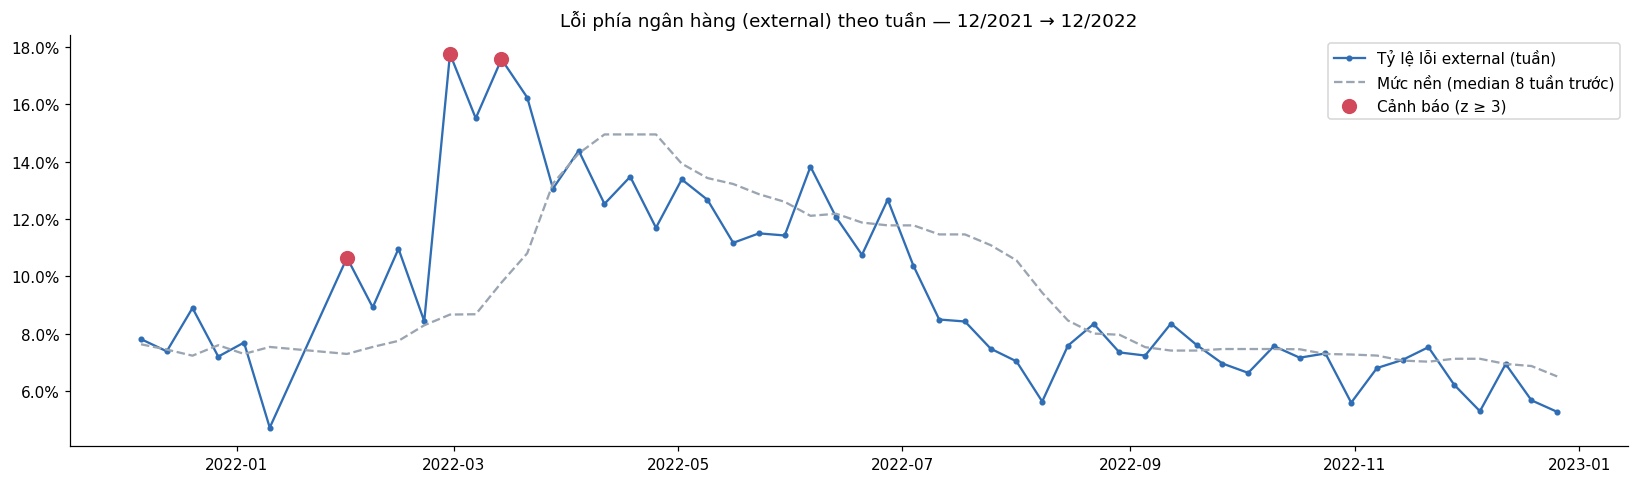

In [3]:
ext = alerts[(alerts["error_group"] == "external") & (alerts["week"] >= "2021-12-01")]
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(ext["week"], ext["rate"], color=BLUE, marker="o", ms=3, label="Tỷ lệ lỗi external (tuần)")
ax.plot(ext["week"], ext["baseline"], color=GREY, ls="--", label="Mức nền (median 8 tuần trước)")
hits = ext[ext["is_alert"]]
ax.scatter(hits["week"], hits["rate"], color=RED, s=80, zorder=3, label="Cảnh báo (z ≥ 3)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title("Lỗi phía ngân hàng (external) theo tuần — 12/2021 → 12/2022")
ax.legend()
plt.tight_layout()
alerts[alerts["is_alert"] & (alerts["week"].dt.year == 2022)][["week", "error_group", "n_tickets", "rate", "baseline", "z", "excess_errors"]].round(3)

In [4]:
monthly = df[df["year"] == 2022].groupby("year_month").agg(
    tickets=("ticket_id", "count"), external_rate=("error_group", lambda s: (s == "external").mean()))
monthly.round(3).T

year_month,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12
tickets,564.000,4206.000,4713.000,5403.000,13209.000,8640.000,17740.000,5531.000,7864.000,9810.000,8280.000,8774.000
external_rate,0.078,0.097,0.162,0.134,0.123,0.122,0.097,0.071,0.072,0.072,0.068,0.061


**Backtest trên đợt lỗi ngân hàng 2022:**
- Tín hiệu đầu tiên: tuần **31/01/2022** lỗi external 10.7% so với mức nền 7.3% (z = 4.7).
- Tuần **28/02 → 06/03/2022**: tỷ lệ lỗi external **17.8%**, gấp đôi mức nền **8.7%** (z = 5.0) → hệ thống cảnh báo ngay **thứ Hai 07/03/2022**.
- Nếu chỉ xem báo cáo tháng: tháng 3/2022 (16.2%) chỉ được thấy khi chốt số **đầu tháng 4** → cảnh báo tuần đi trước khoảng **3–4 tuần**.
- Tỷ lệ lỗi external còn ở mức cao (12–14%) suốt tháng 4–6/2022 — đủ lâu để một cảnh báo sớm tạo ra khác biệt.
- **Không hoàn hảo:** năm 2022 có 6 cảnh báo, 3 cái thuộc đợt lỗi ngân hàng; 3 cái còn lại ở nhóm `internal`/`customer` (trong đó tuần 03/01 chỉ có 195 vé và tỷ lệ 1.5% → gần như chắc chắn là nhiễu). Cách cải thiện: nâng ngưỡng số vé tối thiểu cho nhóm lỗi hiếm, hoặc yêu cầu 2 tuần liên tiếp mới báo đỏ.

## 2. Pipeline hằng tuần: bản tin + danh sách cứu đơn
Chạy lại pipeline cho đúng tuần xảy ra sự cố:

In [5]:
out_dir, summary = pipeline.run("2022-02-28")
print("Thư mục kết quả:", out_dir.relative_to(out_dir.parents[2]))
print("Nguồn bản tin:", summary["brief_sources"])
print(f"Danh sách cứu đơn: {summary['recovery_list_size']} khách")

Thư mục kết quả: reports\weekly\2022-02-28
Nguồn bản tin: {'marketing': 'template (LLM_MODE=off)', 'customer_care': 'template (LLM_MODE=off)', 'product_it': 'template (LLM_MODE=off)', 'finance': 'template (LLM_MODE=off)', 'leadership': 'template (LLM_MODE=off)'}
Danh sách cứu đơn: 175 khách


In [6]:
from IPython.display import Markdown
Markdown((out_dir / "brief_product_it.md").read_text(encoding="utf-8"))

# Product / IT - tuần 2022-02-28 → 2022-03-06
_Nguồn: template (LLM_MODE=off)_

## Payment failed from bank trên mobile / bank account: 21.1% (nền 4.6%)

1,019 lượt thanh toán, tỷ lệ thành công 80.8% (8 tuần trước: 82.4%). CẢNH BÁO: lỗi phía ngân hàng 17.8% (mức nền 8.7%, z = 5.0).

### Điểm chính
- 1,019 lượt thanh toán, tỷ lệ thành công 80.8% (8 tuần trước: 82.4%).
- CẢNH BÁO: lỗi phía ngân hàng 17.8% (mức nền 8.7%, z = 5.0).
- Payment failed from bank · mobile · bank account: 21.1% so với 4.6% (+16.5 điểm %, vượt mức bình thường 74 lỗi).
- Payment failed from bank · mobile · debit card: 36.5% so với 19.6% (+16.9 điểm %, vượt mức bình thường 26 lỗi).
- Payment failed from bank · mobile · credit card: 24.5% so với 21.5% (+2.9 điểm %, vượt mức bình thường 3 lỗi).
- Theo phương thức: debit card 36.9% vs money in app 2.3%.

### Hành động đề xuất
| Việc cần làm | Phụ trách | Chỉ số theo dõi |
|---|---|---|
| Làm việc với ngân hàng / cổng thanh toán về tổ hợp lỗi tăng mạnh nhất | Product / IT | Tỷ lệ lỗi nhóm external theo tuần |
| Thiết kế retry flow: thanh toán lại, đổi phương thức, giữ vé tạm thời | Product | Tỷ lệ hoàn tất thanh toán trên app |
| Gợi ý phương thức ít lỗi hơn ở checkout cho giao dịch rủi ro cao (A/B test) | Product | Tỷ lệ thanh toán thành công |


In [7]:
pd.read_csv(out_dir / "recovery_list.csv").head()

,ticket_id,customer_id,time,paying_method,status_id,description,message
0,eaf01d04284984d4f024c222877fdbf2,153469,2022-02-28 10:50:36.105,bank account,-5,Payment failed from bank,Thanh toán qua ngân hàng chưa thành công (lỗi ...
1,fa236e67381b5f642452e5e061cb1c0f,225204,2022-02-28 13:10:00.889,debit card,-5,Payment failed from bank,Thanh toán qua ngân hàng chưa thành công (lỗi ...
2,6d289dad923d16589cc162b8dc897bd5,193017,2022-02-28 18:02:45.971,bank account,-2,Insufficient funds in customer account. Please...,Tài khoản chưa đủ số dư nên giao dịch chưa thà...
3,7ffda9cdf5acf28155b41eba56219d9f,224630,2022-03-01 11:46:53.592,money in app,-6,Need verify your account to continue,Bạn cần xác minh tài khoản để tiếp tục thanh t...
4,28fdab0e0d5fd6a4950649784528d4fe,200157,2022-03-01 12:36:46.135,debit card,-5,Payment failed from bank,Thanh toán qua ngân hàng chưa thành công (lỗi ...


## 3. Chống "AI bịa số"
LLM chỉ được nhận **FACTS** (mọi con số đã được Python tính và format sẵn). Sau khi LLM viết xong, `validate_numbers` rút mọi con số trong bản tin ra và đối chiếu với FACTS — có số lạ thì **bỏ bản LLM, dùng template**. Thử với một bản tin cố tình chèn số bịa:

In [8]:
facts = briefs.weekly_facts(df, alerts, "2022-02-28")
honest = briefs.template_brief(facts, "finance")
fake = dict(honest, summary=honest["summary"] + " Ước tính mất 25,000 doanh thu, tỷ lệ lỗi tăng 9.1%.")
print("Bản tin đúng  ->", briefs.validate_numbers(honest, facts) or "hợp lệ")
print("Bản tin có số bịa ->", briefs.validate_numbers(fake, facts))

Bản tin đúng  -> hợp lệ
Bản tin có số bịa -> ['25,000', '9.1%']


## 4. Hỏi dữ liệu bằng tiếng Việt (Text-to-SQL)
LLM nhận mô tả schema và sinh **một câu SELECT**; câu lệnh được kiểm tra (chỉ SELECT, một câu, không từ khóa sửa dữ liệu) và chạy trên SQLite **chỉ-đọc**.

Để đo độ chính xác, `eval/ask_data_eval.json` có 12 câu hỏi kèm **SQL đáp án chuẩn**. Đáp án chuẩn:

In [9]:
conn = ask_data.build_connection(df)
gold = [(q["id"], q["question"], ask_data.run_sql(conn, q["gold_sql"]).iloc[0].tolist()) for q in ask_data.load_eval()]
pd.DataFrame(gold, columns=["id", "câu hỏi", "đáp án chuẩn (dòng đầu)"]).set_index("id")

,câu hỏi,đáp án chuẩn (dòng đầu)
id,,
1,Có tổng cộng bao nhiêu lượt thanh toán?,[154725]
2,Có bao nhiêu khách hàng khác nhau từng thực hi...,[119477]
3,Tỷ lệ thanh toán thành công của năm 2022 là ba...,[0.8835265057951739]
4,Phương thức thanh toán nào có tỷ lệ lỗi cao nhất?,[debit card]
5,Mã lỗi nào xuất hiện nhiều nhất?,[Payment failed from bank]
6,Doanh thu năm 2021 là bao nhiêu?,[84427.45]
7,Phim nào bán được nhiều vé thành công nhất?,[Doctor Strange In The Multiverse Of Madness]
8,Tháng nào có nhiều lượt thanh toán nhất?,[2022-07]
9,Năm 2022 có bao nhiêu giao dịch lỗi thuộc nhóm...,[9105]


In [10]:
try:
    ask_data.run_sql(conn, "DELETE FROM tickets")
except ValueError as exc:
    print("Chặn câu lệnh nguy hiểm:", exc)

Chặn câu lệnh nguy hiểm: Chỉ cho phép câu lệnh SELECT


Chạy đánh giá với Gemini thật (mỗi câu ít nhất 1 lần gọi API — tốn hạn mức gói miễn phí, nên mặc định tắt).

Lần chạy ngày 2026-10-09 (chạy bằng script ngoài notebook, cùng hàm `ask_data.run_eval`): **12/12 câu đúng**, khoảng 146 giây.
Các câu do nhiều model khác nhau trả lời (`gemini-3.7-flash`, `gemini-3-flash-preview`, `gemini-3.6-flash`) vì model chính
`gemini-3.5-flash` đã hết hạn mức trong ngày → chuỗi model dự phòng tự chuyển.

In [11]:
RUN_LLM_EVAL = False  # đổi thành True khi đã có GEMINI_API_KEY trong .env

if RUN_LLM_EVAL:
    result = ask_data.run_eval(conn)
    print(f"Độ chính xác: {result['correct'].sum()}/{result['correct'].notna().sum()}")
    display(result[["id", "question", "sql", "correct"]])
else:
    print("Bỏ qua đánh giá LLM (RUN_LLM_EVAL = False)")

Bỏ qua đánh giá LLM (RUN_LLM_EVAL = False)


## 5. Tự động hóa
- `python -m src.pipeline` — chạy tuần gần nhất; `--week YYYY-MM-DD` để chạy lại một tuần bất kỳ; `--notify` gửi tóm tắt qua Telegram.
- `.github/workflows/weekly_pipeline.yml` — GitHub Actions chạy pipeline mỗi sáng thứ Hai, lưu báo cáo thành artifact. API key và Telegram token để trong **GitHub Secrets**, không nằm trong code.
- `app/streamlit_app.py` — giao diện cho quản lý: tổng quan, cảnh báo, bản tin theo tuần, hỏi dữ liệu.